## Running kinGEMs Pipeline on $E. coli$ core Model

In [ ]:

%load_ext autoreload
%autoreload 2

import os
import sys
import pandas as pd # type: ignore
import matplotlib.pyplot as plt # type: ignore
import cobra # type: ignore
import numpy as np # type: ignore
from datetime import datetime
import random
from cobra.io import write_sbml_model # type: ignore
import cobra as cb

# Add parent directory to Python path
sys.path.append(os.path.abspath('..'))

# Import kinGEMs components
import kinGEMs
from kinGEMs.dataset import load_model, convert_to_irreversible, prepare_model_data, retrieve_sequences, map_metabolites, merge_substrate_sequences, process_merged_data_with_folds, process_kcat_predictions, assign_kcats_to_model, format_kcats_like_gpr, annotate_model_with_kcat_and_gpr
from kinGEMs.modeling.optimize import run_optimization_with_dataframe, validate_enzyme_constraints, build_pyomo_fba, solve_pyomo_fba, run_linprog_fba
from kinGEMs.modeling.tuning import simulated_annealing, analyze_kcat_changes
from kinGEMs.modeling.fva import flux_variability_analysis, plot_flux_variability, plot_cumulative_fvi_distribution


2025-06-10 13:15:02.003 | INFO     | kinGEMs.config:<module>:12 - PROJ_ROOT path is: C:\Users\Rana\OneDrive\Documents\GitHub\kinGEMs_v2


### Set your GEM name here

In [2]:

# === Configuration ===
organism_strain_GEMname = "ecoli_core"
organism = "E coli"
run_id = f"{organism_strain_GEMname}_{datetime.today().strftime('%Y%m%d')}_{random.randint(1000, 9999)}"

# Directories
data_dir = "../data"
raw_data_dir = os.path.join(data_dir, "raw")
interim_data_dir = os.path.join(data_dir, "interim")
interim_data_dir_spec = os.path.join(interim_data_dir, f"{organism_strain_GEMname}")
processed_data_dir = os.path.join(data_dir, "processed")
processed_data_dir_spec = os.path.join(processed_data_dir, f"{organism_strain_GEMname}")
CPIPred_data_dir = os.path.join(interim_data_dir, "CPI-Pred predictions")
results_dir = os.path.join(os.getcwd(), "results")
tuning_results_dir = os.path.join(results_dir, "tuning_results", run_id)
os.makedirs(tuning_results_dir, exist_ok=True)

# Input files
model_path = os.path.join(raw_data_dir, "e_coli_core.xml")
predictions_csv_path = os.path.join(CPIPred_data_dir, f"X06A_kinGEMs_{organism_strain_GEMname}_predictions.csv")

# Output files
substrates_output = os.path.join(interim_data_dir_spec, f"{organism_strain_GEMname}_substrates.csv")
sequences_output = os.path.join(interim_data_dir_spec, f"{organism_strain_GEMname}_sequences.csv")
merged_data_output = os.path.join(interim_data_dir_spec, f"{organism_strain_GEMname}_merged_data.csv")
processed_data_output = os.path.join(processed_data_dir_spec, f"{organism_strain_GEMname}_processed_data.csv")

# Simulation parameters
biomass_reaction = 'BIOMASS_Ecoli_core_w_GAM'
enzyme_upper_bound = 0.125


### Step 1: Preparing and processing model data

In [3]:

print("=== Step 1: Preparing model data ===")
irrev_model, substrate_df, sequences_df = prepare_model_data(
    model_path=model_path,
    substrates_output=substrates_output,
    sequences_output=sequences_output,
    organism=organism
)


=== Step 1: Preparing model data ===
Set parameter Username
Academic license - for non-commercial use only - expires 2026-02-25
Loaded model with 95 reactions and 72 metabolites
Read LP format model from file C:\Users\Rana\AppData\Local\Temp\tmpgmkjjzfl.lp
Reading time = 0.01 seconds
: 72 rows, 190 columns, 720 nonzeros
Converted to irreversible model with 154 reactions
Extracted 264 substrate-reaction pairs


c:\Users\Rana\OneDrive\Documents\GitHub\kinGEMs_v2\kinGEMs\dataset.py:164: DtypeWarning: Columns (4,10) have mixed types. Specify dtype option on import or set low_memory=False.
  SEED_comps = pd.read_csv(SEED_COMPOUNDS, sep='\t')
2025-06-10 13:15:31,319 - kinGEMs.dataset - INFO - There are 71 substrates in the GEM.
2025-06-10 13:15:31,352 - kinGEMs.dataset - INFO - -----------------------------
2025-06-10 13:15:31,352 - kinGEMs.dataset - INFO - Mapping substrate: atp_c
2025-06-10 13:15:31,387 - kinGEMs.dataset - INFO - BiGG Name: ATP C10H12N5O13P3
2025-06-10 13:15:31,426 - kinGEMs.dataset - INFO - SMILES found in MetaNetX: Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)([O-])OP(=O)([O-])OP(=O)([O-])[O-])[C@@H](O)[C@H]1O
2025-06-10 13:15:31,427 - kinGEMs.dataset - INFO - -----------------------------
2025-06-10 13:15:31,427 - kinGEMs.dataset - INFO - Mapping substrate: f6p_c
2025-06-10 13:15:31,459 - kinGEMs.dataset - INFO - BiGG Name: D-Fructose 6-phosphate
2025-06-10 13:15:31,498 - kinGEMs.datas

Mapped metabolites to SMILES (264 found)


2025-06-10 13:15:40,871 - root - WARNING - No sequence found for gene s0001


Retrieved 136 protein sequences


### Step 2: Merging substrate and sequence data

In [4]:

print("=== Step 2: Merging substrate and sequence data ===")
merged_data = merge_substrate_sequences(
    substrate_df=substrate_df,
    sequences_df=sequences_df,
    model=irrev_model,
    output_path=merged_data_output
)


=== Step 2: Merging substrate and sequence data ===


### Step 3: Processing CPI-Pred kcat values

In [5]:

print("=== Step 3: Processing CPI-Pred kcat values ===")
processed_data = process_kcat_predictions(
    merged_df=merged_data,
    predictions_csv_path=predictions_csv_path,
    output_path=processed_data_output
)


=== Step 3: Processing CPI-Pred kcat values ===


In [8]:
from cobra.util.array import create_stoichiometric_matrix
import numpy as np 
from scipy.optimize import linprog
# 1. Load model & build S
cobra_model = cobra.io.read_sbml_model(model_path)
S = create_stoichiometric_matrix(cobra_model)     # shape = (n_mets, n_rxns)
res = cobra_model.optimize()

# Build the Pyomo model (no kcat constraints)
pm = build_pyomo_fba(irrev_model, biomass_reaction,
                     convert_irreversible=False)

pm_reversible = build_pyomo_fba(cobra_model, biomass_reaction, convert_irreversible=False)

# Solve and compare
biomass_fba, fluxes_fba = solve_pyomo_fba(pm)
print("Pyomo simple optimization solution:", biomass_fba)

# Solve and compare (reversible model)
biomass_fba_reversible, fluxes_fba_reversible = solve_pyomo_fba(pm_reversible)
print("Pyomo simple optimization solution on reversible model:", biomass_fba_reversible)

# SciPy linprog FBA
b_lin, f_lin = run_linprog_fba(cobra_model, biomass_reaction, reversible=True)
print("SciPy linear programming solution: ", b_lin)

print("COBRA biomass FBA solution:", res.objective_value)

NameError: name 'build_pyomo_fba' is not defined

### Step 4: Simulated Annealing

=== Step 4: Running simulated annealing ===
____________________
Simulated Annealing for tuning kcat function
Optimization completed successfully!
Total reaction-gene pairs: 227
Enzyme-constrained pairs: 0
Unconstrained pairs (missing data): 227
Initial working biomass: 0.018493372838034986
Iteration 1
Optimization completed successfully!
Total reaction-gene pairs: 227
Enzyme-constrained pairs: 0
Unconstrained pairs (missing data): 227
Change in biomass: 0.00000
Biomass with tuned kcats: 0.01849337284014743

Iteration 2
Optimization completed successfully!
Total reaction-gene pairs: 227
Enzyme-constrained pairs: 0
Unconstrained pairs (missing data): 227
Change in biomass: 0.00000
Biomass with tuned kcats: 0.018493372838036846

Iteration 3
Optimization completed successfully!
Total reaction-gene pairs: 227
Enzyme-constrained pairs: 0
Unconstrained pairs (missing data): 227
Change in biomass: 0.00000
Biomass with tuned kcats: 0.018493372838036194

Iteration 4
Optimization completed succe

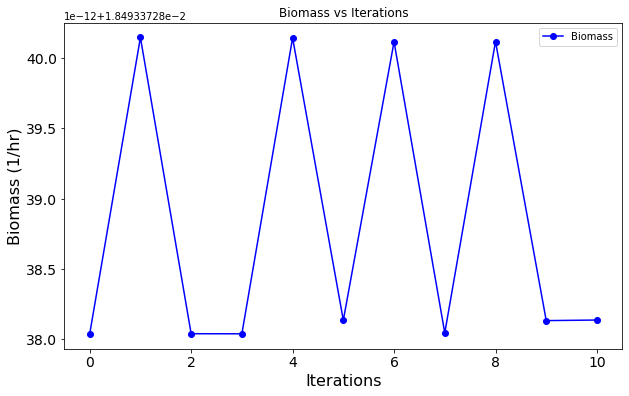

In [6]:

print("=== Step 4: Running simulated annealing ===")
temperature = 1.0
cooling_rate = 0.98
min_temperature = 0.01
max_iterations = 100
max_unchanged_iterations = 10
change_threshold = 0.001

kcat_dict, df_enzyme_sorted, df_new, iterations, biomasses, df_FBA = simulated_annealing(
    model=irrev_model,
    processed_data=processed_data,
    biomass_reaction=biomass_reaction,
    output_dir=tuning_results_dir,
    enzyme_fraction=enzyme_upper_bound,
    temperature=temperature,
    cooling_rate=cooling_rate,
    min_temperature=min_temperature,
    max_iterations=max_iterations,
    max_unchanged_iterations=max_unchanged_iterations,
    change_threshold=change_threshold
)

print(f"Final biomass: {biomasses[-1]}")
print(f"Improvement: {(biomasses[-1] - biomasses[0]) / biomasses[0] * 100:.2f}%")


### Step 5: FVA 

=== Step 5: Running Flux Variability Analysis ===
=== Starting FVA with enzyme constraints ===
Optimization completed successfully!
Total reaction-gene pairs: 227
Enzyme-constrained pairs: 0
Unconstrained pairs (missing data): 227
Optimal biomass: 0.018493
[1/154] FVA for: PFK
Optimization completed successfully!
Total reaction-gene pairs: 227
Enzyme-constrained pairs: 0
Unconstrained pairs (missing data): 227
Optimization completed successfully!
Total reaction-gene pairs: 227
Enzyme-constrained pairs: 0
Unconstrained pairs (missing data): 227
[2/154] FVA for: PFL
Optimization completed successfully!
Total reaction-gene pairs: 227
Enzyme-constrained pairs: 0
Unconstrained pairs (missing data): 227
Optimization completed successfully!
Total reaction-gene pairs: 227
Enzyme-constrained pairs: 0
Unconstrained pairs (missing data): 227
[3/154] FVA for: PGI
Optimization completed successfully!
Total reaction-gene pairs: 227
Enzyme-constrained pairs: 0
Unconstrained pairs (missing data): 227


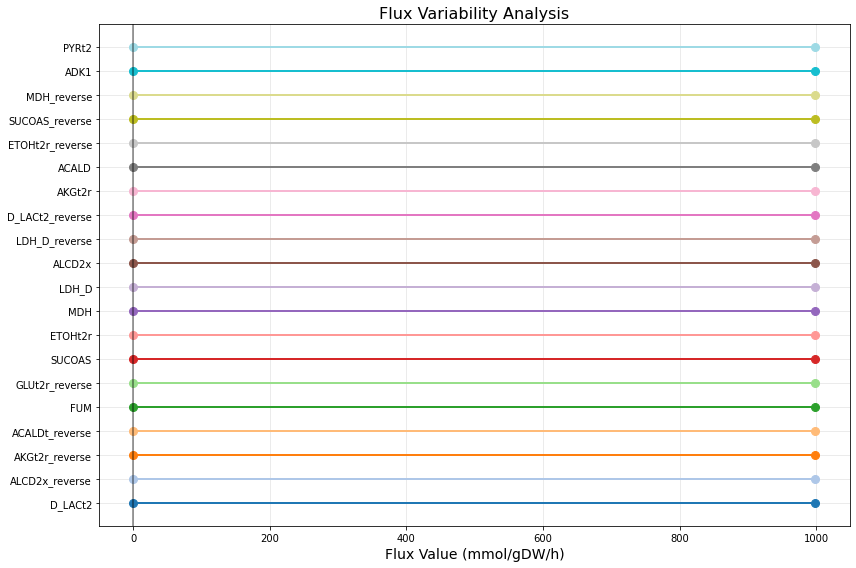

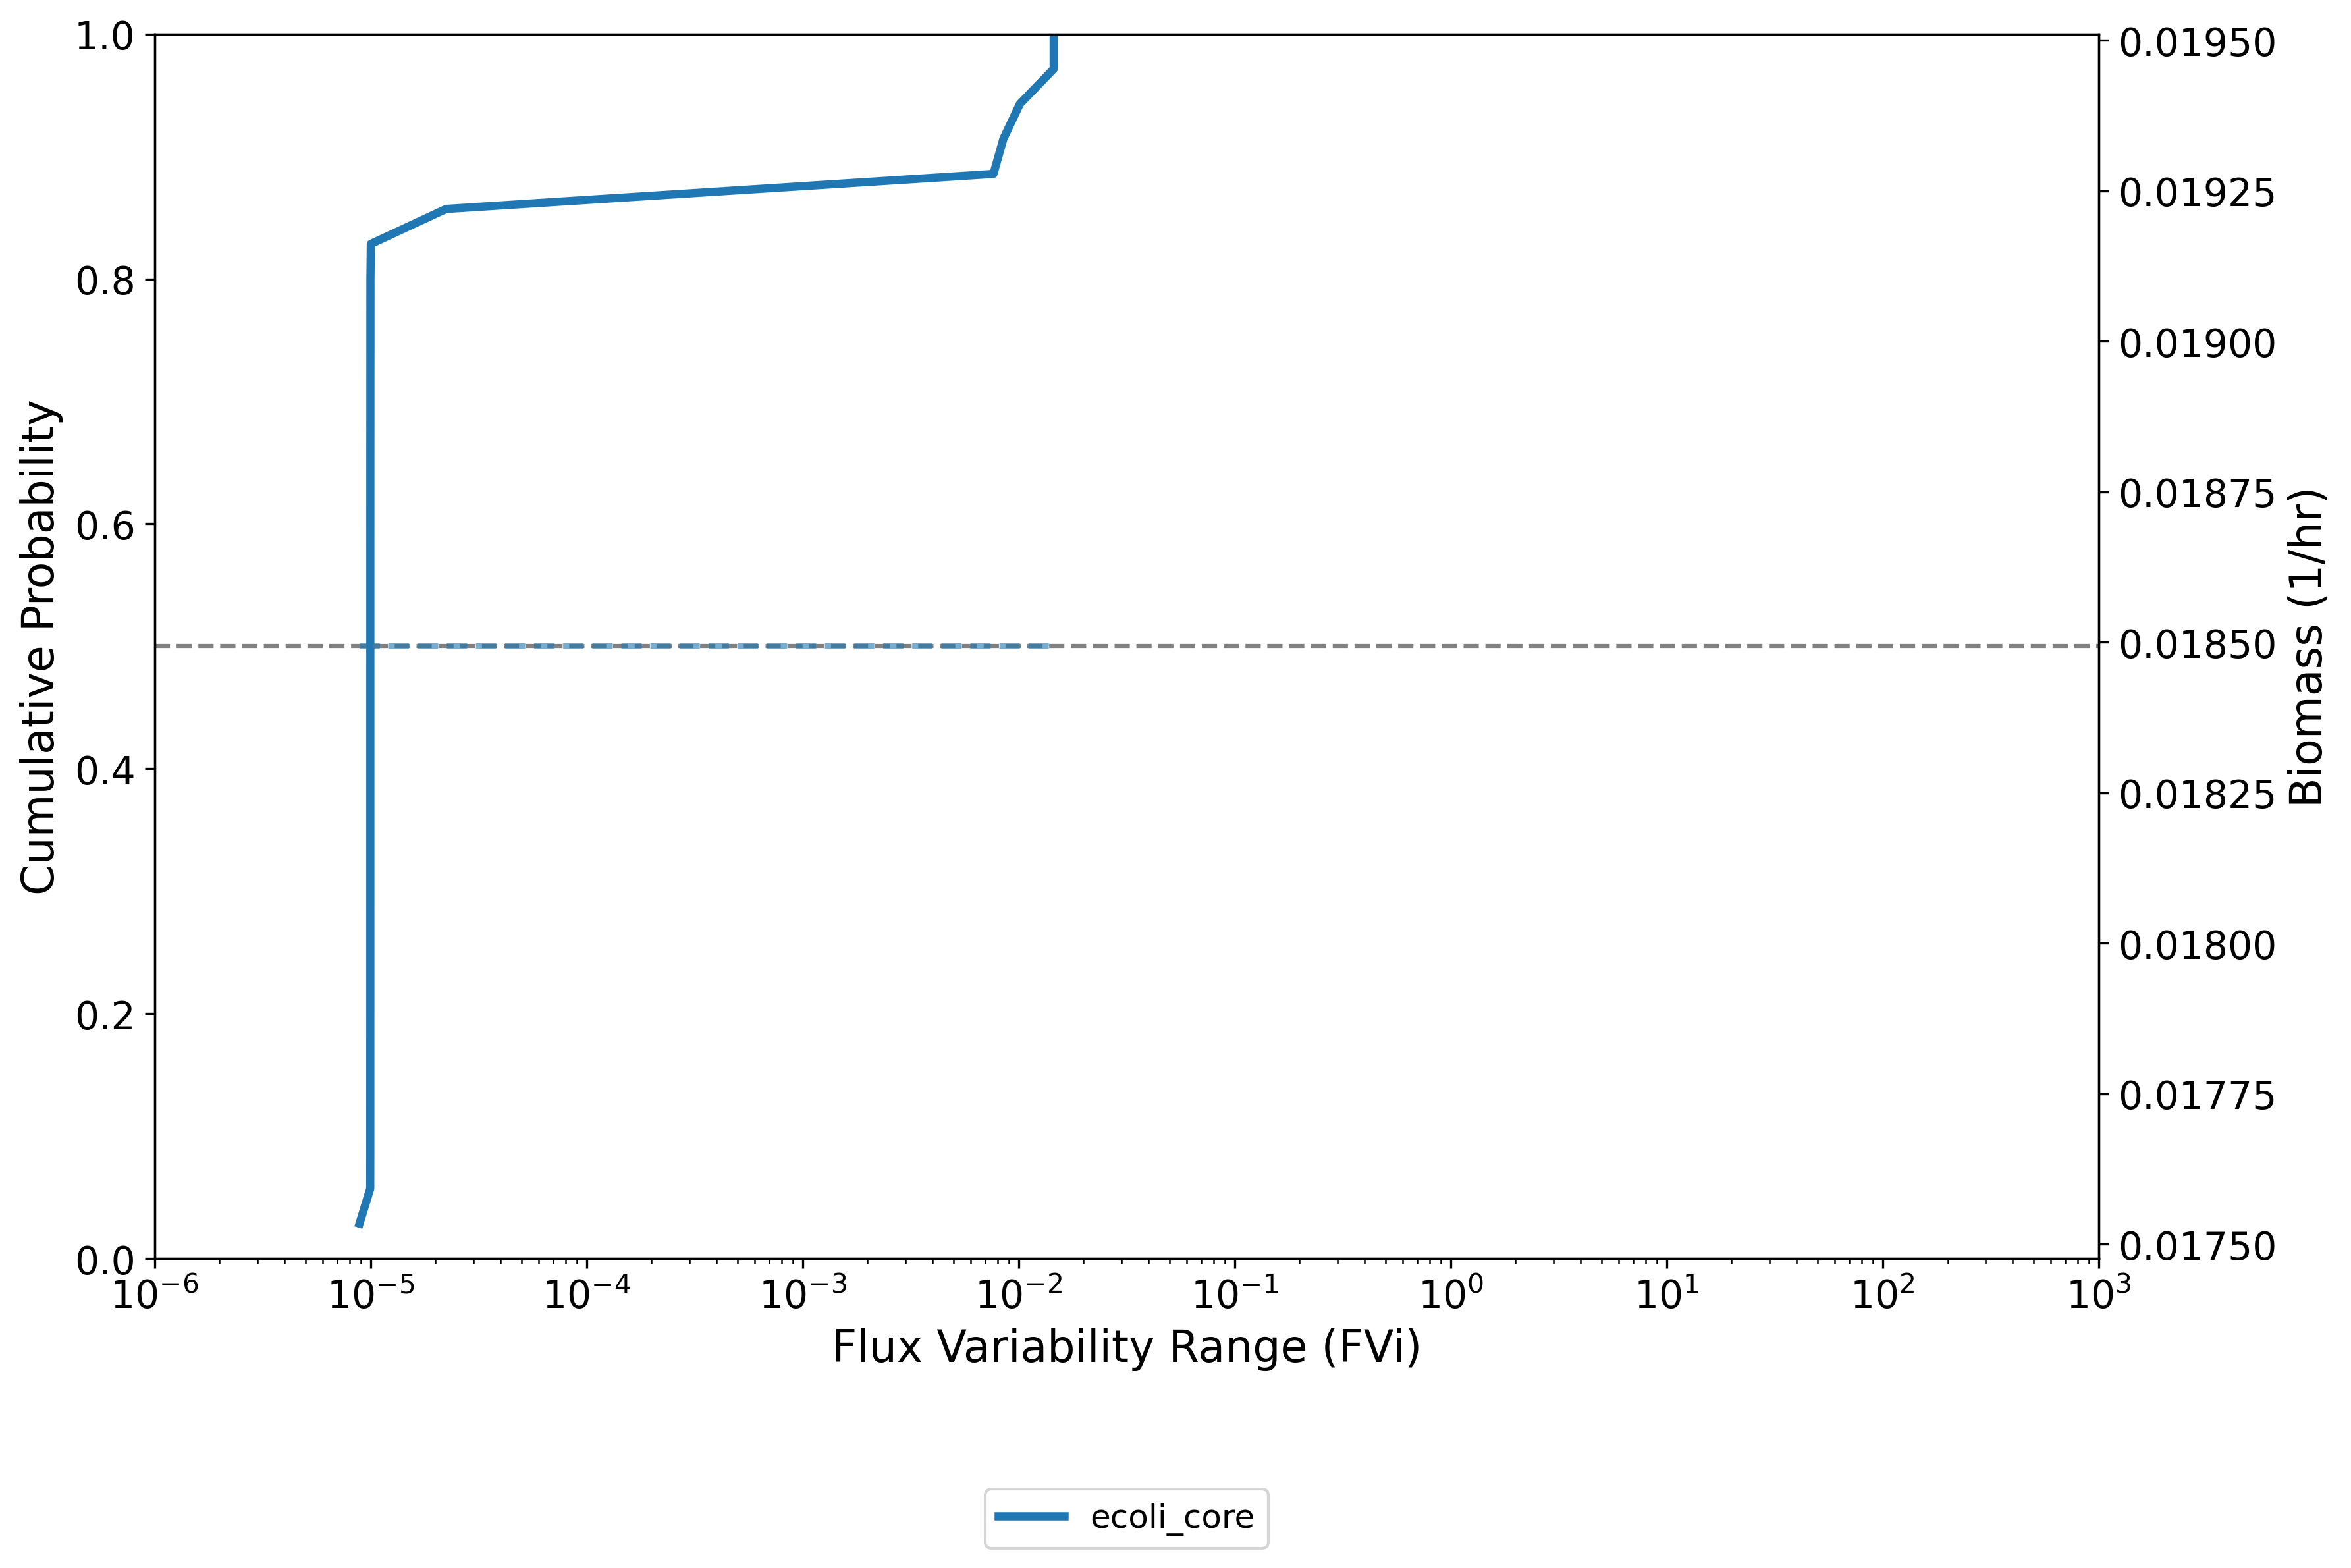

In [7]:

print("=== Step 5: Running Flux Variability Analysis ===")
fva_results_path = os.path.join(tuning_results_dir, f"{organism_strain_GEMname}_fva_results.csv")
fva_plot_path = os.path.join(tuning_results_dir, f"{organism_strain_GEMname}_fva_flux_range_plot.png")
fva_cumulative_path = os.path.join(tuning_results_dir, f"{organism_strain_GEMname}_fva_cumulative_plot.png")

fva_results, _, _ = flux_variability_analysis(
    model=irrev_model,
    processed_df=df_new,
    biomass_reaction=biomass_reaction,
    output_file=fva_results_path,
    enzyme_upper_bound=enzyme_upper_bound
)

# Plot standard FVA range
fig = plot_flux_variability(fva_results, output_file=fva_plot_path)

# Plot cumulative distribution
plot_cumulative_fvi_distribution(
    dfs=[fva_results],
    labels=[organism_strain_GEMname],
    output_file=fva_cumulative_path
)


### Step 6: Save Final Model

In [ ]:
# Define output path for final GEM
models_dir = "../models"
model_output_path = os.path.join(models_dir, f"{run_id}.xml")

# After simulated annealing
model_with_kcats = assign_kcats_to_model(irrev_model, df_new)

# Preview:
format_kcats_like_gpr(model_with_kcats.reactions.get_by_id("PGI"))


# Save the final irreversible model
write_sbml_model(model_with_kcats, model_output_path)

print(f"Final GEM saved to: {model_output_path}")

Final GEM saved to: ../models\ecoli_core_20250515_8518.xml


: 